### Simulate the Monty Hall Problem

- Simulate three doors, one car, and two goats.
 - Simulate three players: the switcher, the conservative, and the newcomer. 
 - Record who wins.
 - Repeat it many times.
 - Which player do you want to be?
 
 - What would happen if you had 100 doors to choose from and the presenter opens 98 or them?
 
- And what if you had $N$ doors to choose from and the presenter opens $M\leq N-2$ of them? Study how the probability of winning changes as a function of $M$ and $N$.

In [ ]:
#monty hall with N_DOORS doors: thre presenters opens all of them besides 2
import numpy as np

N_DOORS = 100
N_COUNTS = 10000


results = {'S': 0, 'C': 0, 'N': 0}

for n in range(N_COUNTS):
    car = np.random.randint(N_DOORS)
    choice = np.random.randint(N_DOORS)

    if choice != car:
        other_choice = car
    else:
        other_choice = -1
        while other_choice < 0:
            i = np.random.randint(N_COUNTS)
            if i != choice:
                other_choice = i

    change = np.random.randint(2)

    if choice == car: results['C'] = results['C']+1
    if other_choice == car: results['S'] = results['S']+1

    if change and other_choice == car: results['N'] = results['N']+1
    if not change and choice == car: results['N'] = results['N']+1

print(results)

{'S': 9899, 'C': 101, 'N': 5006}


### Pdf of the log
1. Use `numpy` to draw $N$ (where $N$ is large...) random samples from a uniform distribution between $0.1$ and $10$, and store these samples as $x$.
2. Use matplotlib to make a histogram of these samples.
3. Compute the base-10 log of your array $x$, and store this as $y$.
4. Make another histogram for $y$. Using the equation to transform probability distributions, write what the theoretical pdf of $y$ is, and overplot it onto your histogram.
5. Compute the log of the mean of $x$ and the mean of $y$. Now compute the log of the median of $x$ and the median of $y$. 

You should note that the means are different, but the medians (as it is a cumulative statistic) are the same. The mean is affected by the scale of the sample values, but the median only depends on the ordering of the samples. Monotonic transformations (like taking the log) do not change the ordering of samples.
 

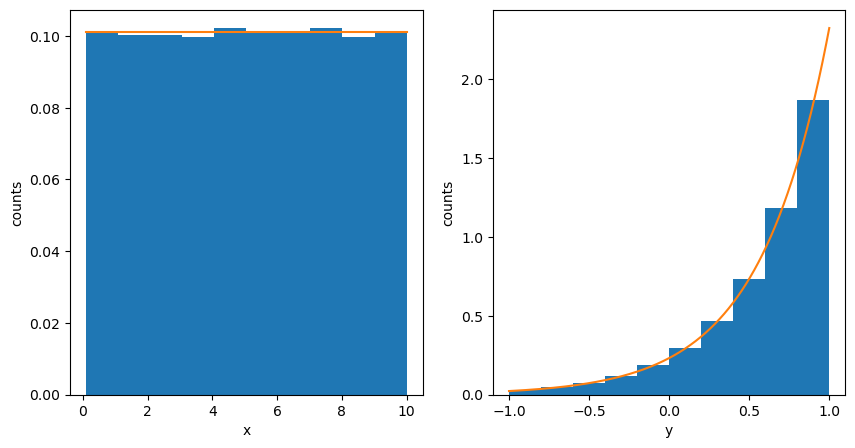

In [23]:
import numpy as np
import matplotlib.pyplot as plt

N = 100000

# Generate x values (uniform)
x = np.random.uniform(0.1, 10, N)

#transform y values (log10)
y = np.log10(x)

#plot histograms (normalized)
plt, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].hist(x, density=True)
axs[1].hist(y, density=True)

axs[0].set_xlabel("x")
axs[0].set_ylabel("counts")
axs[1].set_xlabel("y")
axs[1].set_ylabel("counts")

#plot x pdf
x_space = np.linspace(0.1, 10, 1000)
axs[0].plot(x_space, np.full((1000, 1), fill_value=1/(10-0.1)))

#plot y pdf
def f_y(y):
    return 10**y * np.log(10) / (10-0.1)

x_space = np.linspace(-1, 1, 1000)
y_space = f_y(x_space)
axs[1].plot(x_space, np.full((1000,), fill_value=y_space))
